This file includes the clustering mechanism and algorithms used to determine the resting locations of cattle in the valley and includes some unused plots and probes. It also contains multiple clustering classifications, but through field observations and relations to topographical data, the cluster_norm1 is accorded to be more realistic.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

cows = pd.read_csv('../Data/dades_class.csv')


In [3]:
from sklearn.preprocessing import MinMaxScaler
#This tells us based on Resting parameter determination and GPS error how to plot our heatmaps. 
#Same criteria should be used for cluster determinatio

#filter resting during nights so we only take into account these specific hours.
cows['time'] = pd.to_datetime(cows['time'])
cows['hour'] = cows['time'].dt.hour
cows['date'] = cows['time'].dt.date

cows['night_date'] = np.where(
    cows['hour'] >= 20,
    cows['date'],  # same day
    cows['date'] - pd.to_timedelta(1, unit='D')  # previous day
)
cows = cows[(cows['hour'] >= 20) | (cows['hour'] < 8)]
print(cows["activity"].value_counts())

# finds a stationary window of 7 consecutive data points (which is roughly 80 min) and ensures that a point stays 
# rather close all the time. This is based on the assumption that cattle will rest in a single patch during the night.

def find_stationary_window_scaled(group, window_size=7, min_window_size=4):
    group = group.sort_values('time').reset_index(drop=True)
    n = len(group)

    if n < min_window_size:
        return pd.Series({
            'lat': group['lat'].median(),
            'lng': group['lng'].median(),
            'elevation': group['elevation'].median(),
            'n_points': -1
        })

    scaler = MinMaxScaler()
    movement_features = group[['dist_prev', 'STD_SQRT']].fillna(0)
    scaled = scaler.fit_transform(movement_features)
    group['scaled_dist'] = scaled[:, 0]
    group['scaled_std'] = scaled[:, 1]
    group['movement_score'] = np.sqrt(group['scaled_dist']**2 + group['scaled_std']**2)

    best_score = np.inf
    best_window = None

    for w_size in range(window_size, min_window_size - 1, -1):  # try from largest to smallest
        for i in range(n - w_size + 1):
            window = group.iloc[i:i+w_size]
            if (window['activity'] == 'Grazing').any():
                continue
            score = window['movement_score'].sum()
            if score < best_score:
                best_score = score
                best_window = window
        if best_window is not None:
            break  # stop at first valid window of max possible size

    if best_window is not None:
        return pd.Series({
            'lat': best_window['lat'].median(),
            'lng': best_window['lng'].median(),
            'elevation': best_window['elevation'].median(),
            'n_points': len(best_window)
        })
    else:
        return pd.Series({
            'lat': group['lat'].median(),
            'lng': group['lng'].median(),
            'elevation': group['elevation'].median(),
            'n_points': -1
        })


# Apply to the gdf
stationary_cows = cows.groupby(['id', 'night_date']).apply(find_stationary_window_scaled).reset_index()
print(stationary_cows['n_points'].value_counts())

activity
Resting     643089
Grazing     225603
No Class      6892
Name: count, dtype: int64
n_points
 7.0    15014
-1.0       88
 6.0       61
 5.0       47
 4.0       25
Name: count, dtype: int64


In [4]:
# Count how many -1 entries each cow has (when considerec stationary), and further allows us to reconsider those
# individuals that are moving much more
bad_counts = stationary_cows[stationary_cows['n_points'] == -1]['id'].value_counts()

# Count total entries per cow
total_counts = stationary_cows['id'].value_counts()

# Combine into a DataFrame
ratios = (bad_counts / total_counts).fillna(0).sort_values(ascending=False)
ratios = ratios.rename("bad_ratio").reset_index().rename(columns={"index": "id"})

print(ratios.head(50))

            id  bad_ratio
0   AQ259_2023   0.117117
1   AR460_2023   0.081081
2   CJ315_2023   0.068627
3   AJ723_2023   0.061947
4   AQ275_2023   0.053097
5   AJ727_2023   0.047170
6   AQ935_2023   0.035088
7   AQ938_2023   0.026316
8   AJ719_2023   0.026316
9   AQ302_2023   0.026316
10  CJ371_2023   0.026316
11  CJ367_2023   0.017544
12  AR442_2023   0.017544
13  CJ350_2023   0.017544
14  AJ707_2023   0.017544
15  AR449_2023   0.017544
16  AQ929_2021   0.010309
17  AR444_2021   0.010101
18  AR449_2021   0.010101
19  AR454_2021   0.010101
20  AR607_2021   0.010101
21  AQ259_2022   0.009174
22  AR450_2022   0.009174
23  AJ705_2022   0.009174
24  AQ256_2023   0.008772
25  AJ717_2023   0.008772
26  CJ361_2023   0.008772
27  CJ369_2023   0.008772
28  AJ706_2023   0.008772
29  AR430_2023   0.008772
30  AJ702_2023   0.008772
31  AR457_2021   0.000000
32  AR456_2022   0.000000
33  AR453_2021   0.000000
34  AR458_2021   0.000000
35  AR455_2023   0.000000
36  AJ701_2022   0.000000
37  AR452_20

In [5]:
import geopandas as gpd
from statsmodels.nonparametric.kernel_density import KDEMultivariate

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    stationary_cows,
    geometry=gpd.points_from_xy(stationary_cows["lng"], stationary_cows["lat"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator (meters)
gdf = gdf.to_crs(epsg=3857)
x = gdf.geometry.x.values
y = gdf.geometry.y.values

# Estimate bandwidths from the data
kde = KDEMultivariate(data=[x, y], var_type="cc")
bw_x, bw_y = kde.bw
print(f"Default bandwidths (meters): x = {bw_x:.2f}, y = {bw_y:.2f}")

target_radius = 30  # meters

# Compute adjustment factors
bw_adjust_x = target_radius / bw_x
bw_adjust_y = target_radius / bw_y

# Use the smaller one to ensure kernel is not too wide
bw_adjust = min(bw_adjust_x, bw_adjust_y)
print(f"Suggested bw_adjust for ~{target_radius}m kernel: {bw_adjust:.3f}")

Default bandwidths (meters): x = 231.35, y = 184.47
Suggested bw_adjust for ~30m kernel: 0.130


/Users/jan/Desktop/Uni/Biologia/Article/venv/lib/python3.14/site-packages/pandas/util/_decorators.py:220: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


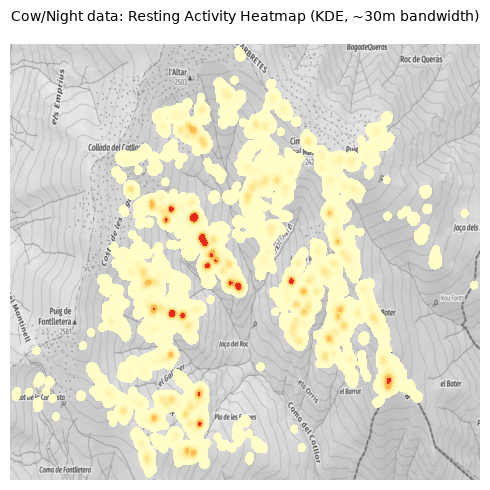

In [6]:
import seaborn as sns
import contextily as ctx

#we make a first kde plot to get an estimate of how the data is sorted in the valley.

fig, ax = plt.subplots(figsize=(5, 5))

sns.kdeplot(
    x=x,
    y=y,
    fill=True,
    cmap="YlOrRd",
    bw_adjust=bw_adjust,
    thresh=0.003,  # or adjust based on how much noise you want to suppress, usually 0.03
    ax=ax
)

#need internet for this to work properly.
icgc_gris_url = "https://geoserveis.icgc.cat/servei/catalunya/mapa-base/wmts/topografic-gris/MON3857NW/{z}/{x}/{y}.png"
ctx.add_basemap(ax, source=icgc_gris_url)
ax.set_title(f"Cow/Night data: Resting Activity Heatmap (KDE, ~{target_radius}m bandwidth)", size=10)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../Plots/Article/baseheatmap.png")
plt.show()
plt.close()

In [10]:
#clustering methods: we find the preffered epsilon for the clustering hdbscan method
from sklearn.preprocessing import StandardScaler
import hdbscan


gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y
gdf["z"] = gdf["elevation"]

# Create 3D array: X, Y, Z
coords_3d = gdf[["x", "y", "z"]].values

# Scale all three dimensions equally
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords_3d)
avg_std = scaler.scale_.mean()  # average std across x, y, z
epsilon_normalized = float(30 / avg_std)
print(f"For a 30m difference: effective epsilon ≈ {epsilon_normalized:.5f} in standard")

For a 30m difference: effective epsilon ≈ 0.04267 in standard


In [11]:
"""
Run HDBSCAN, with min_cluster_size to be chosen, min_samples to be understood and
cluster_selection_epsilon as above. If multiplied by 4, then distances have to be around 
120m to be considered the same

Parameters for cluster choosing:
-> min_cluster_size: the smallest amount of points in a cluster so it is considered as one. Maybe choose
                     in reference to the amount of positions per night we have (median) and then estimate.
                     
-> min_samples: how conservative we want the Excess of Mass algorithm to work, meaning that a higher value
                ranging in (1, min_cluster_size) will determine how strict our clustering routine is. The 
                smaller the value, more clusters, the larger, less clusters.
                
-> cluster_selection_epsilon: calculated from above determines if two positions are considered close-by or
                              not. To know how many meters it refers to, just make avg_std*epsilon,
                              when set to 4*epsilon_normalized it is roughly 120m.

We are aiming at something around a 5-15% of outliers, the smaller the better. Different criteria will
have different results. In order to pass the data, we want a clustering method: "regional" clusters, 
another one seen as "decent amount of clusters", and a complete "small cluster units" that reflects
the heatmap shown before. These 3 points should suffice for the moment.

"""

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,        # How many are the minimal points in a cluster
    min_samples=20,             # How strict HDBSCAN is in terms of positions, 1 would be a lot of small clusters, the higher, the contrary
    cluster_selection_epsilon = 3*epsilon_normalized,
    metric='euclidean'
)
labels = clusterer.fit_predict(coords_scaled)
noise_ratio = (labels == -1).sum()/len(labels)
print(f"Outliers: {noise_ratio:.3%}")


# Count clusters (excluding noise)
unique_labels, counts = np.unique(labels, return_counts=True)
n_clusters = (unique_labels != -1).sum()
print(f"\nNumber of clusters (excluding outliers): {n_clusters}")


Outliers: 6.800%

Number of clusters (excluding outliers): 32


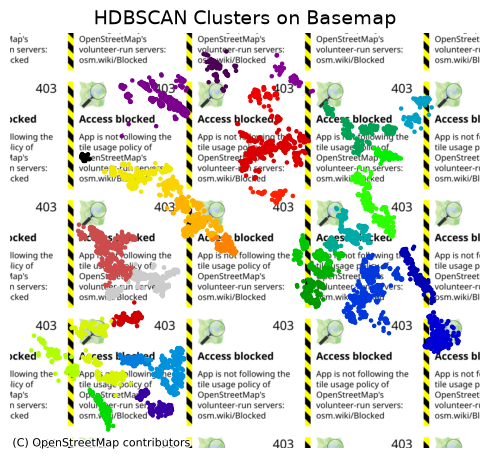

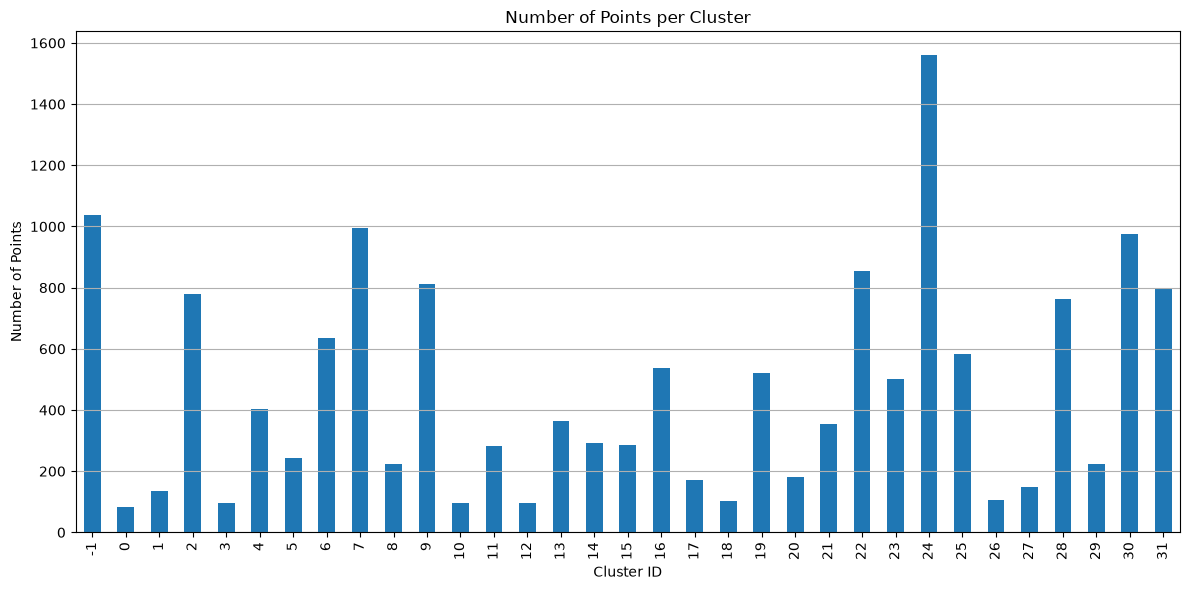

In [12]:
"""
Different clustering methods and possibilities, with the % of outlierrs per each. Norm1 is the article chosen set.
"""

'''
cluster_groller : 
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=600,        # How many are the minimal points in a cluster
    min_samples=50,             # How strict HDBSCAN is in terms of positions, 1 would be a lot of small clusters, the higher, the contrary
    cluster_selection_epsilon = 3*epsilon_normalized,
    metric='euclidean'
)
11 clusters with 9.564% outliers.



cluster_fi:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,        # How many are the minimal points in a cluster
    min_samples=5,             # How strict HDBSCAN is in terms of positions, 1 would be a lot of small clusters, the higher, the contrary
    cluster_selection_epsilon = 2*epsilon_normalized,
    metric='euclidean'
)

80 clusters, with 4.168% outliers.

cluster_norm1:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,        # How many are the minimal points in a cluster
    min_samples=20,             # How strict HDBSCAN is in terms of positions, 1 would be a lot of small clusters, the higher, the contrary
    cluster_selection_epsilon = 3*epsilon_normalized,
    metric='euclidean'
)

33 clusters, with 6.866% outliers.


cluster_norm2:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,        # How many are the minimal points in a cluster
    min_samples=5,             # How strict HDBSCAN is in terms of positions, 1 would be a lot of small clusters, the higher, the contrary
    cluster_selection_epsilon = 2*epsilon_normalized,
    metric='euclidean'
)

43 clusters, with 8.113% outliers.


on epsilon_normalized per a donar una distancia de 30m


'''

# Add to your GeoDataFrame
gdf["cluster_id"] = labels

# Filter out outliers (cluster_id == -1)
clustered_gdf = gdf[gdf["cluster_id"] != -1].copy()

# Make sure it's in Web Mercator (EPSG:3857) for contextily basemap
if clustered_gdf.crs.to_epsg() != 3857:
    clustered_gdf = clustered_gdf.to_crs(epsg=3857)
# Plot
fig, ax = plt.subplots(figsize=(5, 5))
clustered_gdf.plot(column="cluster_id", cmap="nipy_spectral", legend=False, ax=ax, markersize=5)

# Add base map
ctx.add_basemap(ax, source=icgc_gris_url)

# Improve display
ax.set_axis_off()
plt.title("HDBSCAN Clusters on Basemap", fontsize=14)
plt.tight_layout()
#plt.savefig("../Plots/Article/cluster_norm1.png")
plt.show()




cluster_counts = gdf["cluster_id"].value_counts().sort_index()
# Bar plot
plt.figure(figsize=(12, 6))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Points")
plt.title("Number of Points per Cluster")
plt.xticks(rotation=90)  # Rotate x-labels if many clusters
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [13]:
#gdf = gdf.rename(columns= {'cluster_id': 'cluster_norm1'})
gdf

,id,night_date,lat,lng,elevation,n_points,geometry,x,y,z,cluster_id
0,AJ701_2022,2022-07-04,42.368795,2.255116,1874.0,7.0,POINT (251038.319 5216384.283),251038.318825,5.216384e+06,1874.0,-1
1,AJ701_2022,2022-07-05,42.371786,2.248280,2095.0,7.0,POINT (250277.334 5216834.917),250277.334110,5.216835e+06,2095.0,8
2,AJ701_2022,2022-07-06,42.377401,2.248096,2091.0,7.0,POINT (250256.951 5217681.064),250256.950621,5.217681e+06,2091.0,31
3,AJ701_2022,2022-07-07,42.379431,2.245106,2261.0,7.0,POINT (249924.02 5217986.891),249924.019850,5.217987e+06,2261.0,30
4,AJ701_2022,2022-07-08,42.371725,2.243290,2247.0,7.0,POINT (249721.883 5216825.72),249721.883247,5.216826e+06,2247.0,21
...,...,...,...,...,...,...,...,...,...,...,...
15230,CJ375_2023,2023-10-22,42.379110,2.262638,1924.0,7.0,POINT (251875.742 5217938.602),251875.741736,5.217939e+06,1924.0,16
15231,CJ375_2023,2023-10-23,42.379736,2.263325,1969.0,7.0,POINT (251952.18 5218032.881),251952.179932,5.218033e+06,1969.0,16
15232,CJ375_2023,2023-10-24,42.377859,2.269841,1950.0,7.0,POINT (252677.493 5217750.047),252677.493429,5.217750e+06,1950.0,7
15233,CJ375_2023,2023-10-25,42.377890,2.264744,1929.0,7.0,POINT (252110.152 5217754.646),252110.152197,5.217755e+06,1929.0,15


In [14]:
gdf=gdf.drop(columns=['n_points', 'geometry', 'x', 'y', 'z'])
#gdf.to_csv("../Data/dad.csv", index=False)

In [95]:
gdf.to_csv("../Data/dades_clusters.csv", index=False)